# Logistic Regression

In [17]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [18]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Count'>

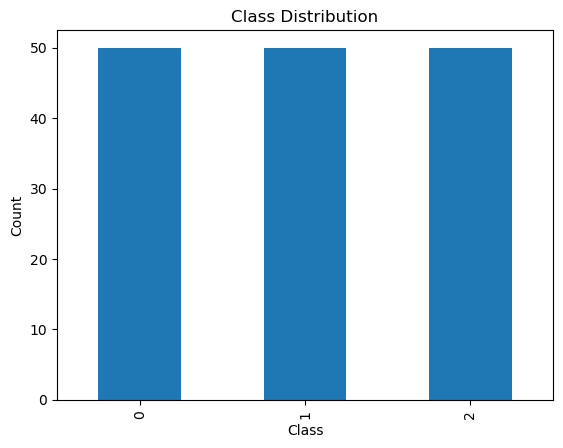

In [19]:
df['target'].value_counts().plot(kind='bar', title='Class Distribution', xlabel='Class', ylabel='Count')

In [20]:
X = df.drop('target', axis=1)
y = (df['target'] == 2).astype(int)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression

In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, solver='saga', l1_ratio=0.5))
])

In [24]:
param_grid = {
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__solver': ['saga']
}

In [25]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'classifier__C': [0.001, 0.01, ...], 'classifier__penalty': ['l1', 'l2', ...], 'classifier__solver': ['saga'], 'scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [26]:
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')
print(f'Test accuracy: {grid_search.score(X_test, y_test):.4f}')

Best parameters: {'classifier__C': 1, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga', 'scaler': MinMaxScaler()}
Best CV accuracy: 0.9667
Test accuracy: 0.9667


O problema desse dataset é muito fácil, por isso o 100%

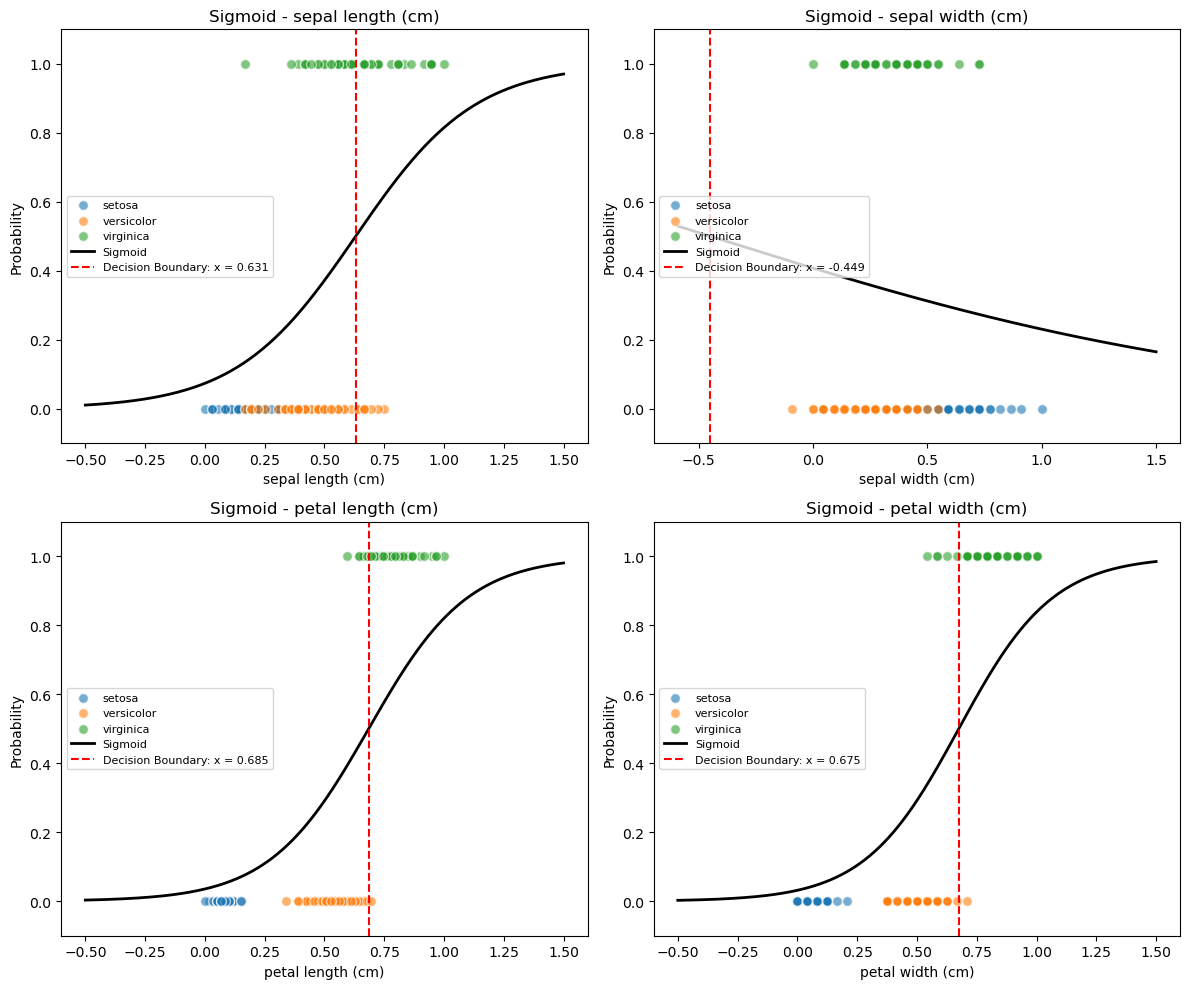

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

best_model = grid_search.best_estimator_.named_steps['classifier']
scaler = grid_search.best_estimator_.named_steps['scaler']
X_scaled = scaler.transform(X)

feature_names = X.columns
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
species_names = iris.target_names

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (ax, feat_name) in enumerate(zip(axes, feature_names)):
    x_feat = X_scaled[:, idx].reshape(-1, 1)
    
    temp_model = LogisticRegression(max_iter=1000)
    temp_model.fit(x_feat, y)
    
    x_range = np.linspace(x_feat.min() - 0.5, x_feat.max() + 0.5, 300).reshape(-1, 1)
    y_proba = temp_model.predict_proba(x_range)[:, 1]
    
    for species_idx in range(3):
        mask = df['target'] == species_idx
        label = 1 if species_idx == 2 else 0
        ax.scatter(X_scaled[mask, idx], [label] * mask.sum(), 
                   c=colors[species_idx], label=species_names[species_idx],
                   alpha=0.6, edgecolors='w', s=50)
    
    ax.plot(x_range, y_proba, 'k-', linewidth=2, label='Sigmoid')
    
    boundary = -temp_model.intercept_[0] / temp_model.coef_[0][0]
    ax.axvline(x=boundary, color='red', linestyle='--', linewidth=1.5,
               label=f'Decision Boundary: x = {boundary:.3f}')
    
    ax.set_xlabel(feat_name)
    ax.set_ylabel('Probability')
    ax.set_title(f'Sigmoid - {feat_name}')
    ax.legend(loc='center left', fontsize=8)
    ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

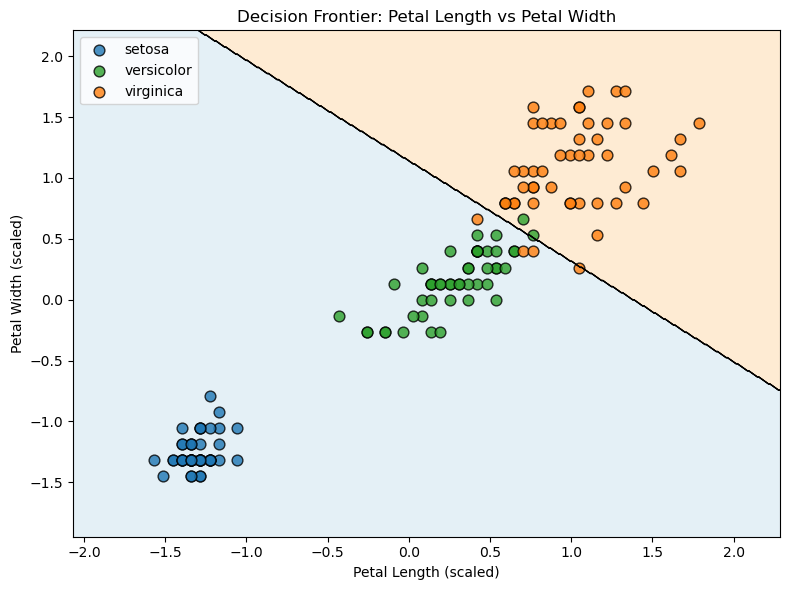

In [28]:
from matplotlib.colors import ListedColormap

X_2d = X[['petal length (cm)', 'petal width (cm)']].values
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_2d_scaled, y)

x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

cmap_background = ListedColormap(['#a6cee3', '#fdbf6f'])
species_colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)
ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

for species_idx in range(3):
    mask = df['target'] == species_idx
    ax.scatter(X_2d_scaled[mask, 0], X_2d_scaled[mask, 1],
               color=species_colors[species_idx], label=iris.target_names[species_idx],
               edgecolors='k', s=60, alpha=0.8)

ax.set_xlabel('Petal Length (scaled)')
ax.set_ylabel('Petal Width (scaled)')
ax.set_title('Decision Frontier: Petal Length vs Petal Width')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

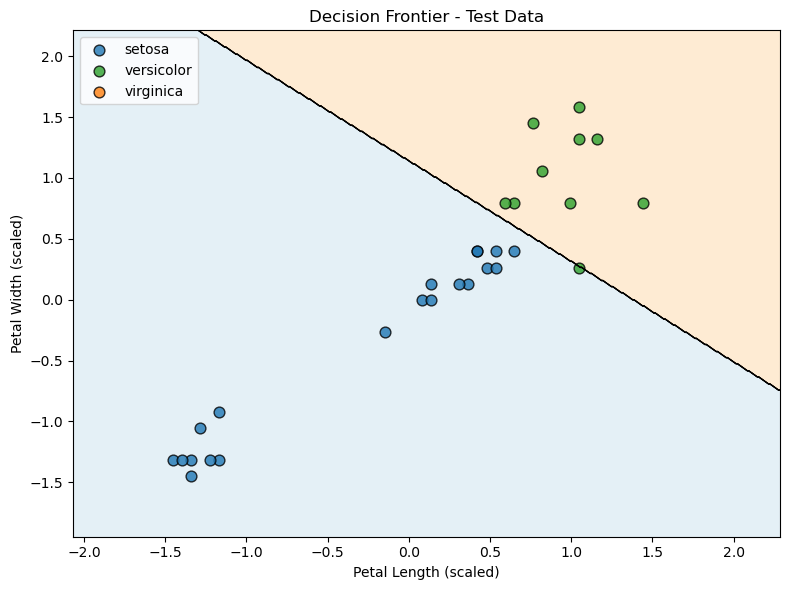

In [29]:
X_test_2d = X_test[['petal length (cm)', 'petal width (cm)']].values
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)
ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

for species_idx in range(3):
    mask = y_test.reset_index(drop=True) == species_idx
    ax.scatter(X_test_2d_scaled[mask, 0], X_test_2d_scaled[mask, 1],
               color=species_colors[species_idx], label=iris.target_names[species_idx],
               edgecolors='k', s=60, alpha=0.8)

ax.set_xlabel('Petal Length (scaled)')
ax.set_ylabel('Petal Width (scaled)')
ax.set_title('Decision Frontier - Test Data')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

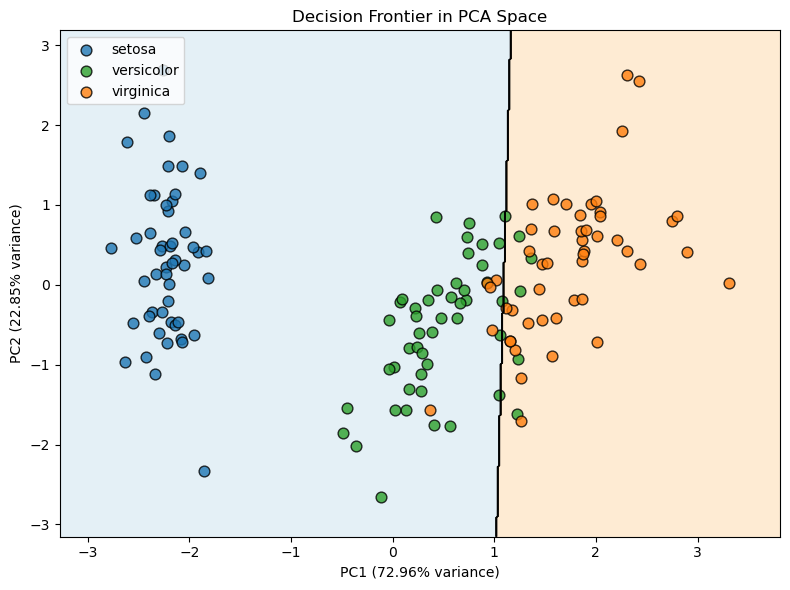

In [30]:
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled_full = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_pca, y)

x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

cmap_background = ListedColormap(['#a6cee3', '#fdbf6f'])
species_colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)
ax.contour(xx, yy, Z, colors='k', linewidths=0.5)

for species_idx in range(3):
    mask = df['target'] == species_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=species_colors[species_idx], label=iris.target_names[species_idx],
               edgecolors='k', s=60, alpha=0.8)

var_explained = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.2f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.2f}% variance)')
ax.set_title('Decision Frontier in PCA Space')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

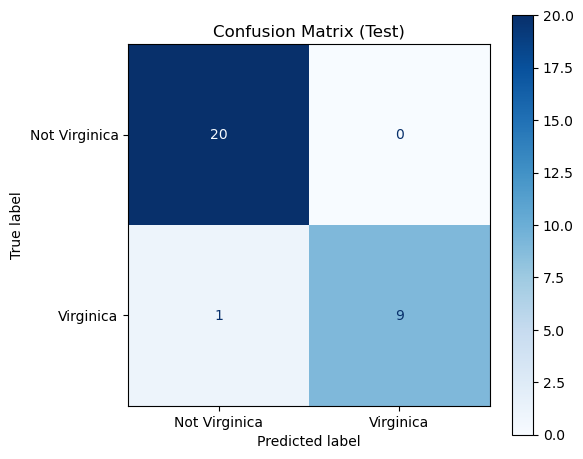

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = grid_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Virginica', 'Virginica'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix (Test)')
plt.tight_layout()
plt.show()

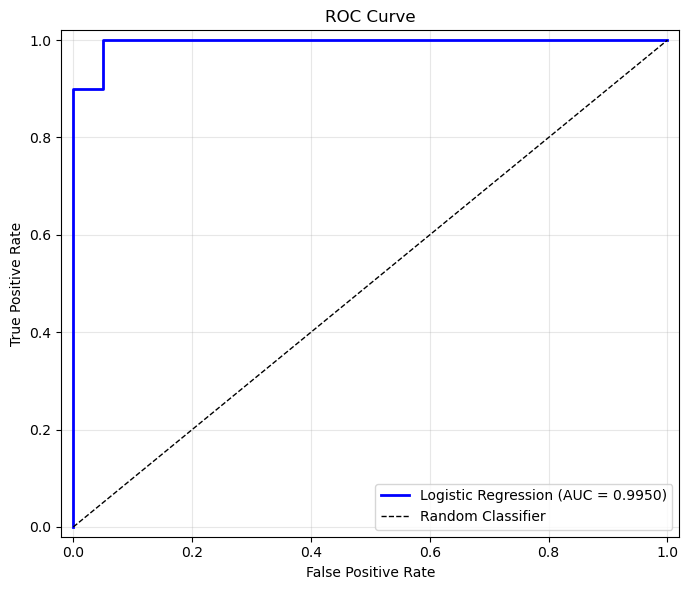

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = grid_search.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()